# Day 4
Logistic Regression
Dataset: Titanic | Project: Survival Classifier

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                               recall_score, f1_score, roc_curve, roc_auc_score, classification_report)
import joblib
pd.set_option('display.max_columns', None)

In [7]:
df = pd.read_csv('//content/drive/MyDrive/14 days of ML/Logistic_Regression_Day4/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

## EDA  Survival Rate Distribution

In [9]:
print(df['Survived'].value_counts())
print("\nSurvival Rate:\n", df['Survived'].value_counts(normalize=True))

Survived
0    549
1    342
Name: count, dtype: int64

Survival Rate:
 Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


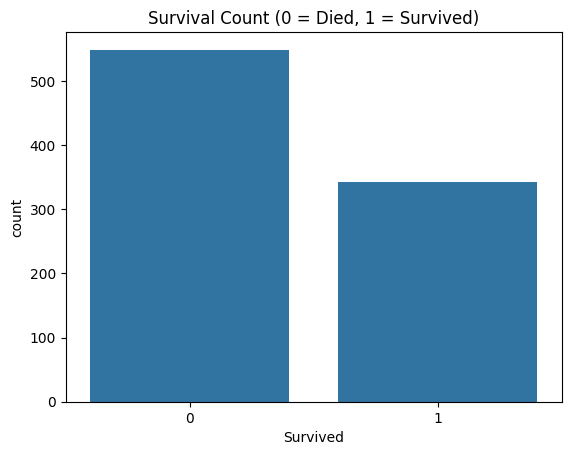

In [10]:
sns.countplot(x='Survived', data=df)
plt.title('Survival Count (0 = Died, 1 = Survived)')
plt.show()

In [11]:
#Quick Overview
print(df.info())
print(df.isnull().sum)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
<bound method DataFrame.sum of      PassengerId  Survived  Pclass   Name    Sex    Age  SibSp  Parch  Ticket  \
0          False     False   False  False  False  False  False  False   False   
1          False     False   False  False  Fal

# Handling Missing Values

In [12]:
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

In [13]:
df = df.drop(columns=['Cabin'])

In [14]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [15]:
print("Remaining missing values:\n", df.isnull().sum())

Remaining missing values:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## Feature Engineering  FamilySize & Title

In [16]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.')
print(df['Title'].value_counts())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


In [17]:
# Tital Mapping
title_map = {
    'Mr': 'Mr',
    'Miss': 'Miss',
    'Mrs': 'Mrs',
    'Master': 'Master',
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs'
}

df['Title'] = df['Title'].map(lambda x: title_map.get(x, 'Rare'))
print(df['Title'].value_counts())

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


##  Droping Irrelevant Columns here

In [18]:
df = df.drop(columns=['Name', 'Ticket', 'PassengerId'])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,Title
0,0,3,male,22.0,1,0,7.2500,S,2,Mr
1,1,1,female,38.0,1,0,71.2833,C,2,Mrs
2,1,3,female,26.0,0,0,7.9250,S,1,Miss
3,1,1,female,35.0,1,0,53.1000,S,2,Mrs
4,0,3,male,35.0,0,0,8.0500,S,1,Mr


## Encoding Categorical Variables (Sex, Embarked, Title)

In [19]:
df = pd.get_dummies(df, columns=['Sex', 'Embarked', 'Title'], drop_first=True)
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,22.0,1,0,7.2500,2,True,False,True,False,True,False,False
1,1,1,38.0,1,0,71.2833,2,False,False,False,False,False,True,False
2,1,3,26.0,0,0,7.9250,1,False,False,True,True,False,False,False
3,1,1,35.0,1,0,53.1000,2,False,False,True,False,False,True,False
4,0,3,35.0,0,0,8.0500,1,True,False,True,False,True,False,False


# Train Test Split

In [20]:
X = df.drop(columns=['Survived'])
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (712, 13)
X_test: (179, 13)


##Feature Scaling

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression Model training and Evaluation

In [22]:
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [23]:
y_pred = model.predict(X_test_scaled)
print(y_pred[:10])

[1 0 0 1 1 1 1 0 1 1]


In [24]:
y_pred_proba = model.predict_proba(X_test_scaled)
print(y_pred_proba[:10])

[[0.38948754 0.61051246]
 [0.81284882 0.18715118]
 [0.89774627 0.10225373]
 [0.1698793  0.8301207 ]
 [0.32243857 0.67756143]
 [0.06649458 0.93350542]
 [0.31057012 0.68942988]
 [0.95335083 0.04664917]
 [0.28349319 0.71650681]
 [0.14006215 0.85993785]]


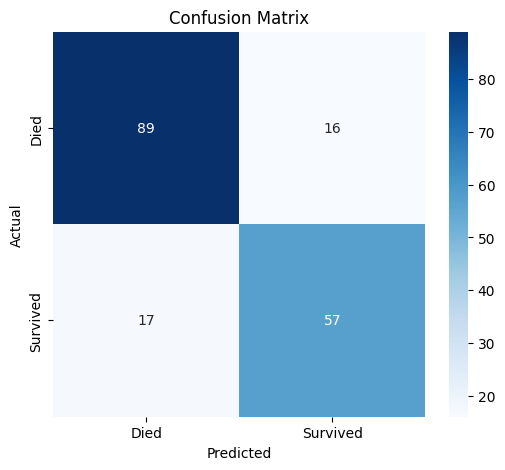

In [25]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Died', 'Survived'], yticklabels=['Died', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [26]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("\nFull Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8156424581005587
Precision: 0.7808219178082192
Recall: 0.7702702702702703
F1 Score: 0.7755102040816326

Full Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.85      0.84       105
           1       0.78      0.77      0.78        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



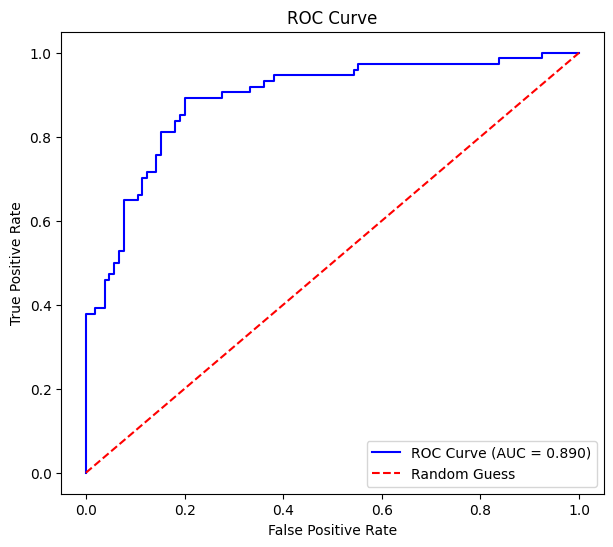

AUC Score: 0.8897039897039898


In [27]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])
auc_score = roc_auc_score(y_test, y_pred_proba[:, 1])
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
print("AUC Score:", auc_score)

In [29]:
# Save Model
joblib.dump(model, 'logistic_regression_model.joblib')
print("Model saved successfully as 'logistic_regression_model.joblib'")

Model saved successfully as 'logistic_regression_model.joblib'
